# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
G = 6.67e-11
ME = 5.9e24
RE = 6378000 # meters
dEM = 3.8e8
MM = 7.3e22
RM = 1737000 # meters
wm = 2.8e6
dm = 7.5e5
br = 1.3e4
ev = 2.4e3
g = 9.81
import matplotlib.pyplot as plt
from scipy.integrate import quad
import math

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def Potential(M, x, y, xm, ym):
    """
    Gravitational potential from a mass M
    parameters - 
    M : float or int - mass of the object
    xm : float or int - x coordinate of the mass
    ym : float or int - y coordinate of the mass
    x : float or int - x coordinate of the arbitrary point
    y : float or int - y coordinate of the arbitrary point

    Returns - float - the gravitational potential (phi)

    Raises:
    TypeError - if inputs are not numeric
    ValueError - if mass is not positive
    ArithmeticError - (x,y) = (xm, ym)
    """
    if not isinstance(M, (int, float)):
        raise TypeError("Mass must be numeric")
    if not isinstance(xm, (int, float)) or not isinstance(ym, (int, float)):
        raise TypeError("Coordinate values must be numeric")
    if not isinstance(x, (int, float)) or not isinstance(y, (int, float)):
        raise TypeError("Coordinate values must be numeric")
    if M <= 0:
        raise ValueError("Mass must be positive")
    r = np.sqrt((x-xm)**2 + (y-ym)**2)
    if np.isclose(r,0):
        raise ArithmeticError("Error!,  Point equals mass location")
    Phi = -G*M/r
    if not np.isfinite(Phi):
        raise ArithmeticError("Non-physical potential calculated")
    return Phi

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

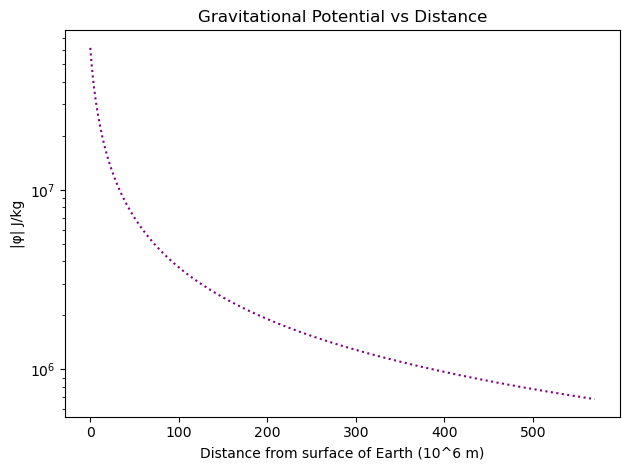

In [4]:
x = np.linspace(0, 1.5*dEM, 400)

r = RE + x
Phi = G*ME/r

fig, ax = plt.subplots()
ax.plot(x/1e6, Phi, color='purple', linestyle='dotted')
ax.set_xlabel("Distance from surface of Earth (10^6 m)")
ax.set_ylabel("|φ| J/kg")
ax.set_title("Gravitational Potential vs Distance")
ax.set_yscale('log')
fig.tight_layout()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

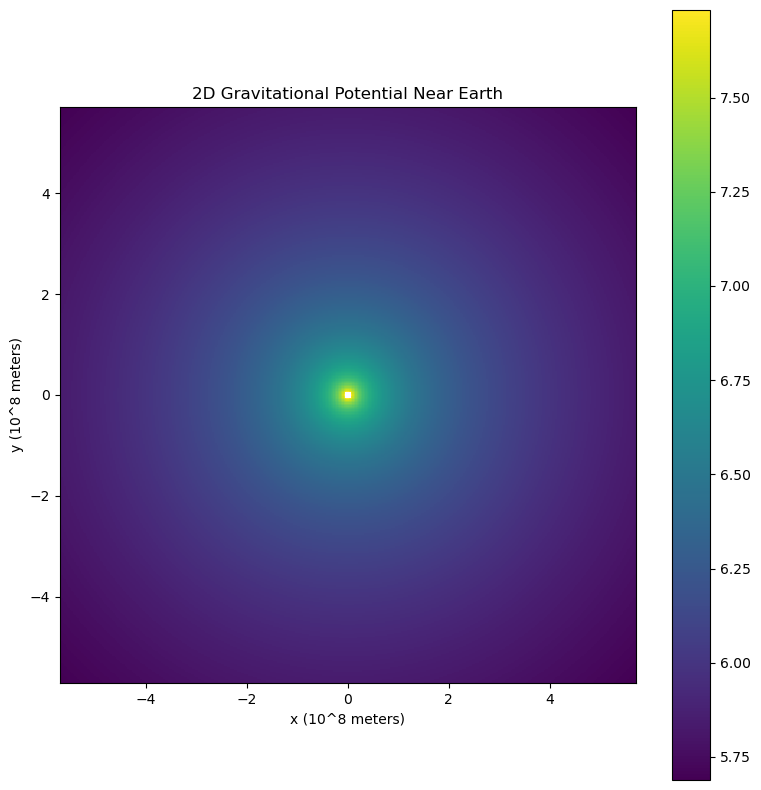

In [5]:
grid = np.linspace(-1.5*dEM, 1.5*dEM, 400)
X, Y = np.meshgrid(grid, grid)

R = np.sqrt(X**2 + Y**2)

Phi = G * ME / R
Phi[R < RE] = np.nan
Phi_log = np.log10(Phi)
fig, ax = plt.subplots(figsize=(8, 8))
mesh = ax.pcolormesh(X/1e8, Y/1e8, Phi_log, cmap='viridis')
ax.set_xlabel("x (10^8 meters)")
ax.set_ylabel("y (10^8 meters)")
ax.set_title("2D Gravitational Potential Near Earth")
ax.set_aspect('equal')
fig.colorbar(mesh, ax=ax)
fig.tight_layout()

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

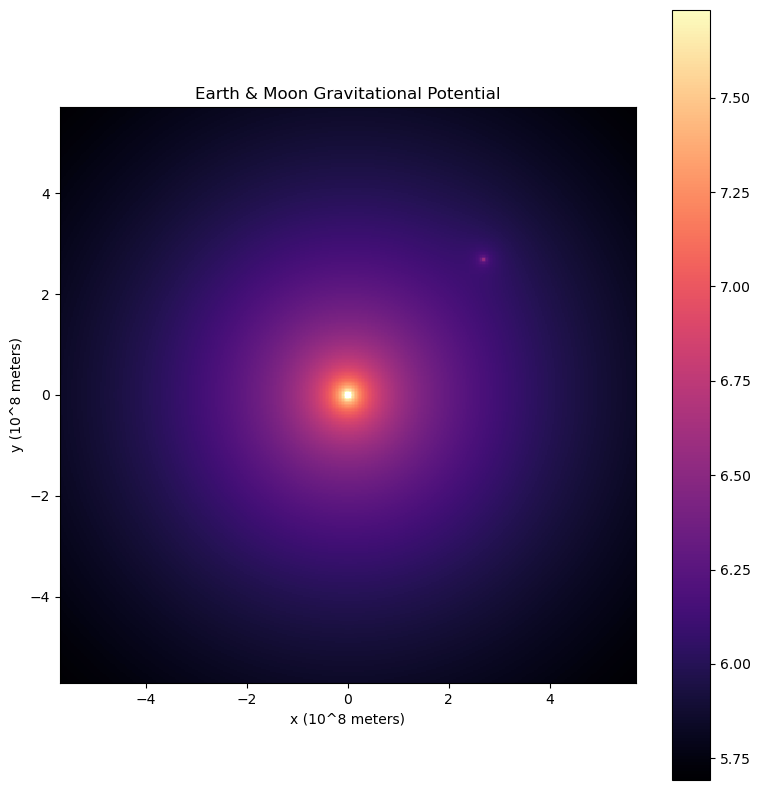

In [6]:
grid = np.linspace(-1.5*dEM, 1.5*dEM, 400)
X, Y = np.meshgrid(grid, grid)

RE_pos = (0, 0)
RM_pos = (dEM/np.sqrt(2), dEM/np.sqrt(2))

R_E = np.sqrt((X - RE_pos[0])**2 + (Y - RE_pos[1])**2)
R_M = np.sqrt((X - RM_pos[0])**2 + (Y - RM_pos[1])**2)
Phi = G*ME/R_E + G*MM/R_M
Phi[R_E < RE] = np.nan
Phi[R_M < RM] = np.nan
Phi_log = np.log10(Phi)
fig, ax = plt.subplots(figsize=(8,8))
mesh = ax.pcolormesh(X/1e8, Y/1e8, Phi_log, cmap='magma')
ax.set_xlabel("x (10^8 meters)")
ax.set_ylabel("y (10^8 meters)")
ax.set_title("Earth & Moon Gravitational Potential")
ax.set_aspect('equal')
fig.colorbar(mesh, ax=ax)
fig.tight_layout()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

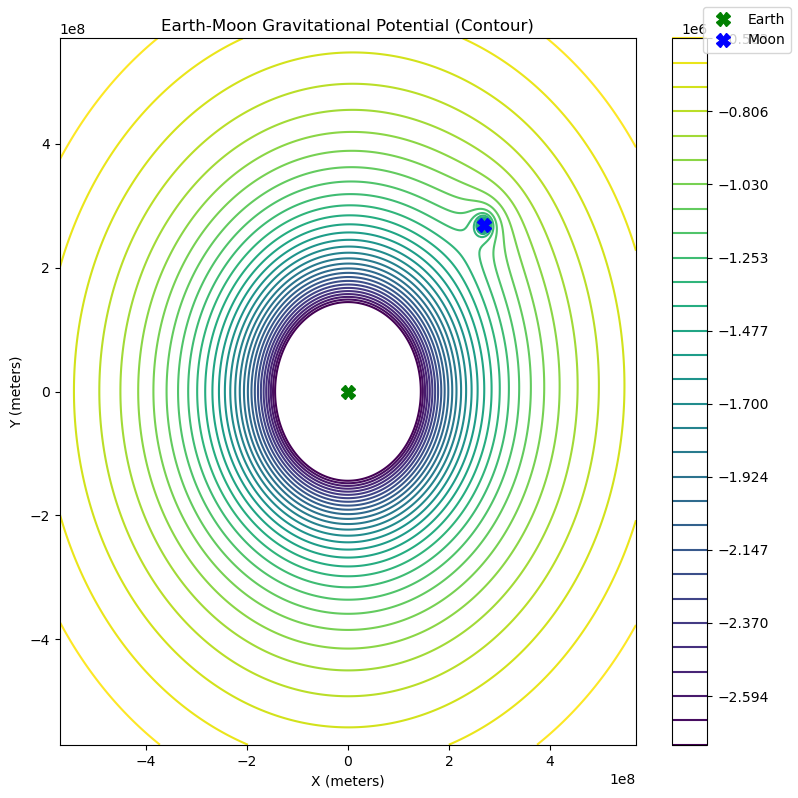

In [7]:
xe, ye = 0, 0
xm, ym = dEM/np.sqrt(2), dEM/np.sqrt(2)
def Phi(x, y):
    RE = np.sqrt((x - xe)**2 + (y - ye)**2)
    RM = np.sqrt((x - xm)**2 + (y - ym)**2)
    phi_earth = np.where(np.isclose(RE, 0, atol=1e-6), np.nan, -G*ME/RE)
    phi_moon = np.where(np.isclose(RM, 0, atol=1e-6), np.nan, -G*MM/RM)
    return phi_earth + phi_moon
a = np.linspace(-1.5*dEM, 1.5*dEM, 400)
x, y = np.meshgrid(a, a)
z = Phi(x, y)
z_max = np.nanpercentile(z, 95)
z_min = np.nanpercentile(z, 5)
levels = np.linspace(z_min, z_max, 30)
fig, ax = plt.subplots(figsize=(8,8))
cont = ax.contour(x, y, z, levels=levels, cmap='viridis')
ax.plot(xe, ye, 'X', color='Green', markersize=10, label='Earth')
ax.plot(xm, ym, 'X', color='Blue', markersize=10, label='Moon')
ax.set_title('Earth-Moon Gravitational Potential (Contour)')
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
fig.colorbar(cont, ax=ax)
fig.legend()
fig.tight_layout()

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def gravitational_force(M1, M2, x1, y1, x2, y2):
    """
    Compute gravitational force on mass M2 due to M1.

    Parameters:
        M1, M2   Masses of the objects
        x1, y1   coordinates of M1 
        x2, y2   coordinates of M2 

    Returns:
        (Fx, Fy)  - force components in Newtons

    Raises:
        TypeError - if inputs are not numeric
        ValueError - if masses are non-positive
        ArithmeticError - if positions are too close
    """
    for name, val in [("M1",M1),("M2",M2),("x1",x1),("y1",y1),("x2",x2),("y2",y2)]:
        if not isinstance(val, (int, float)):
            raise TypeError(f"{name} must be numeric")
    if M1 <= 0 or M2 <= 0:
        raise ValueError("Masses must be positive")
    dx = x2 - x1
    dy = y2 - y1
    r = np.sqrt(dx**2 + dy**2)
    if np.isclose(r, 0):
        raise ArithmeticError("Singularity: positions coincide")
    Fx = -G * M1 * M2 * dx / r**3
    Fy = -G * M1 * M2 * dy / r**3
    return Fx, Fy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

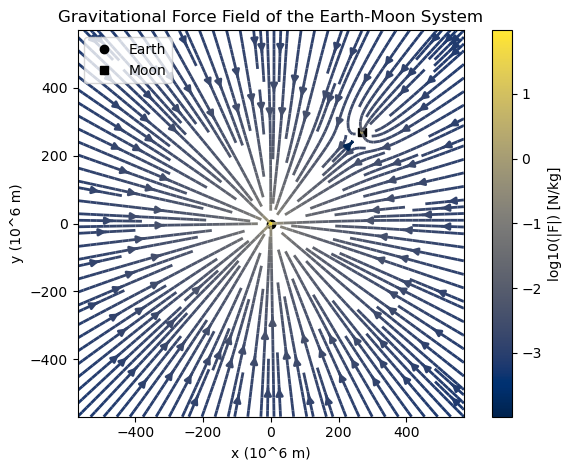

In [9]:
earth_pos = (0, 0)
moon_pos = (dEM/np.sqrt(2), dEM/np.sqrt(2))

fig, ax = plt.subplots(1,1)

ax.plot([earth_pos[0]/1e6], [earth_pos[1]/1e6], 'ko', label='Earth')
ax.plot([moon_pos[0]/1e6], [moon_pos[1]/1e6], 'ks', label='Moon')

nx, ny = 400, 400
x = np.linspace(-1.5*dEM, 1.5*dEM, nx)
y = np.linspace(-1.5*dEM, 1.5*dEM, ny)
X, Y = np.meshgrid(x, y)
Fx_total = np.zeros_like(X)
Fy_total = np.zeros_like(Y)

for i in range(nx):
    for j in range(ny):
        xi, yi = X[i,j], Y[i,j]
        dx_e = xi - earth_pos[0]
        dy_e = yi - earth_pos[1]
        r_e = np.sqrt(dx_e**2 + dy_e**2)
        if np.isclose(r_e, 0):
            Fx_e = 0
            Fy_e = 0
        else:
            Fx_e = -G*ME*dx_e/r_e**3
            Fy_e = -G*ME*dy_e/r_e**3
        
        dx_m = xi - moon_pos[0]
        dy_m = yi - moon_pos[1]
        r_m = np.sqrt(dx_m**2 + dy_m**2)
        if np.isclose(r_m, 0):
            Fx_m = 0
            Fy_m = 0
        else:
            Fx_m = -G*MM*dx_m/r_m**3
            Fy_m = -G*MM*dy_m/r_m**3
        
        Fx_total[i,j] = Fx_e + Fx_m
        Fy_total[i,j] = Fy_e + Fy_m

F_mag = np.sqrt(Fx_total**2 + Fy_total**2)
F_mag[F_mag == 0] = np.nan 

strm = ax.streamplot( X/1e6, Y/1e6, Fx_total, Fy_total, color=np.log10(F_mag), cmap='cividis', density=2, linewidth=2)
plt.colorbar(strm.lines, ax=ax, label='log10(|F|) [N/kg]')
ax.set_xlabel('x (10^6 m)')
ax.set_ylabel('y (10^6 m)')
ax.set_title('Gravitational Force Field of the Earth-Moon System')
ax.legend(loc = 'upper left')
ax.set_aspect('equal')

plt.tight_layout()

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

$$|\vec{F}_{\text{earth}}| = |\vec{F}_{\text{moon}}|$$
$$\frac{GM_{\text{earth}}\, m}{r^2} = \frac{GM_{\text{moon}}\, m}{(d - r)^2}$$
$$\frac{M_{\text{earth}}}{r^2} = \frac{M_{\text{moon}}}{(d - r)^2}$$
$$\frac{\sqrt{M_{\text{earth}}}}{r} = \frac{\sqrt{M_{\text{moon}}}}{d - r}$$
$$\sqrt{M_{\text{earth}}} \,(d - r) = \sqrt{M_{\text{moon}}} \, r$$
$$\sqrt{M_{\text{earth}}} \, d = r \left(\sqrt{M_{\text{earth}}} + \sqrt{M_{\text{moon}}}\right)$$
$$\boxed{r = \frac{d}{1 + \sqrt{M_{\text{moon}} / M_{\text{earth}}}}}$$
$$x_{\text{balance}} = r \cos(45°) = \frac{r}{\sqrt{2}}, \qquad y_{\text{balance}} = r \sin(45°) = \frac{r}{\sqrt{2}}$$
$$\boxed{x_{\text{balance}} = y_{\text{balance}} = \frac{d}{\sqrt{2}\left(1 + \sqrt{M_{\text{moon}} / M_{\text{earth}}}\right)} \approx 2.45 \times 10^{8}\ \text{m}}$$

And your updated plot, including the balance point, goes in the cell below.

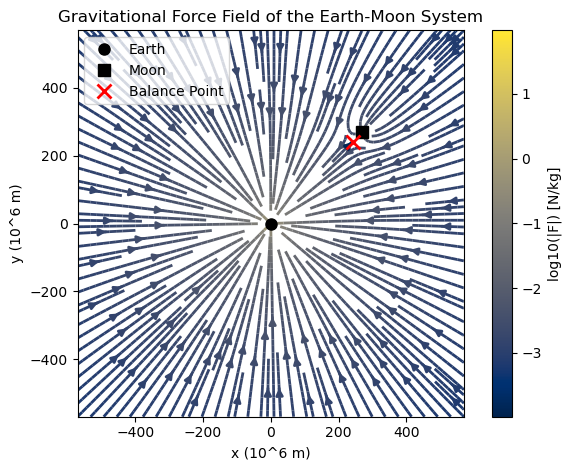

In [10]:
r_balance = dEM / (1 + np.sqrt(MM / ME))
x_balance = r_balance / np.sqrt(2)
y_balance = r_balance / np.sqrt(2)

fig, ax = plt.subplots(1,1)

strm = ax.streamplot(X/1e6, Y/1e6, Fx_total, Fy_total, color=np.log10(F_mag), cmap='cividis', density=2, linewidth=2)

plt.colorbar(strm.lines, ax=ax, label='log10(|F|) [N/kg]')

ax.plot([earth_pos[0]/1e6], [earth_pos[1]/1e6], 'ko', markersize=8, label='Earth')
ax.plot([moon_pos[0]/1e6], [moon_pos[1]/1e6], 'ks', markersize=8, label='Moon')
ax.plot([x_balance/1e6], [y_balance/1e6], 'rx', markersize=10, markeredgewidth=2, label='Balance Point')

ax.set_xlim([-1.5*dEM/1e6, 1.5*dEM/1e6])
ax.set_ylim([-1.5*dEM/1e6, 1.5*dEM/1e6])
ax.set_aspect('equal')
ax.set_xlabel('x (10^6 m)')
ax.set_ylabel('y (10^6 m)')
ax.set_title('Gravitational Force Field of the Earth-Moon System')
ax.legend(loc = 'upper left')
plt.tight_layout()
plt.show()

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

Yes, the results make sence, the balance point is way closer to the Moon than to Earth. About 3.46e8 m from the Earth and about a tenth as close to the moon. This makes sence as the Earth has way more mass than the moon. 

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T = (wm - dm) / br
print("Burn time T seconds:", T)

Burn time T seconds: 157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(t, m0, mf, mdot, ve, g):
    """
    Calculate the change in velocity of a rocket at time t
    using the Tsiolkovsky rocket equation

    Parameters - 
    t - float or int - time elapsed since launch (s)
    m0 - float or int - initial wet mass (kg)
    mf - float or int - final dry mass (kg)
    mdot - float or int - fuel burn rate (kg/s)
    ve - float or int - exhaust velocity (m/s)
    g - float or int - gravitational acceleration (m/s^2)

    Returns - float : change in velocity  in meters per second

    Raises:
    TypeError - if inputs are not numeric
    ValueError - if inputs are non-positive, mf >= m0, or t < 0
    ArithmeticError - if the result is non-physical
    """
    if not isinstance(t, (int, float)):
        raise TypeError("Time 't' must be numeric!")
    if not isinstance(m0, (int, float)):
        raise TypeError("Initial mass 'm0' must be numeric!")
    if not isinstance(mf, (int, float)):
        raise TypeError("Final mass 'mf' must be numeric!")
    if not isinstance(mdot, (int, float)):
        raise TypeError("Fuel burn rate 'mdot' must be numeric!")
    if not isinstance(ve, (int, float)):
        raise TypeError("Exhaust velocity 've' must be numeric!")
    if not isinstance(g, (int, float)):
        raise TypeError("Gravity 'g' must be numeric!")

    if t < 0:
        raise ValueError("Time 't' cannot be negative!")
    if m0 <= 0 or mf <= 0:
        raise ValueError("Masses must be positive and non-zero!")
    if mf >= m0:
        raise ValueError("Final dry mass 'mf' must be less than initial mass 'm0'!")
    if mdot <= 0:
        raise ValueError("Fuel burn rate 'mdot' must be positive!")
    if ve <= 0:
        raise ValueError("Exhaust velocity 've' must be positive!")
    if g < 0:
        raise ValueError("Gravity 'g' must be non-negative!")

    T = (m0 - mf) / mdot

    mt = m0 - mdot * t

    if t >= T:
        dv = ve * math.log(m0 / mf) - g * T
    else:
        try:
            dv = ve * math.log(m0 / mt) - g * t
        except:
            raise ArithmeticError("Non-physical Δv calculated! Check inputs.")

    if not math.isfinite(dv) or dv < 0:
        raise ArithmeticError("Non-physical Δv calculated!")

    return dv

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
T = (wm - dm)/br

def integrand(t):
    return delta_v(t, wm, dm, br, ev, g)

h, error = quad(integrand, 0, T)
print("Total burn time:", T, "s")
print("Altitude at burnout:", h, "m")

Total burn time: 157.69230769230768 s
Altitude at burnout: 74093.98013366401 m


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**